# Deep Learning - 2026

## Problem Definition

### Context

Wind turbines generate electricity from wind. More and more states and private companies are investing in renewable energies and building wind turbine plants. Knowing the installed capacity and wind turbine locations could help in energy production forecast - in the case of wind turbines, public records are very accurate and the whole fleet is already mapped in databases, but this exercise serves a wider purpose. Deep Learning could help identify and count wind turbines on satellite image. 

A similar exercise could be done for example, on solar panels for which there's distributed micro generation which is harder to completely map from public databases.

### Objective

The objective is split into two stages:

1. Perform Binary Classification, detecting if images **contain** or do **not contain** wind turbines.
2. Perform **Turbine Counting** (Multi-class Classification).

### Limitation

The dataset found with multiple wind turbines to allow for counting, doesn't have a lot of images (~3.5k total images), and I thought this could be a limitation.
To work around this limitation, I have decided to use another dataset which is much larger (357k train + 71k validation) but contains only one turbine per image which doesn't allow for counting which is the exercise I want to do.
This is a limitation that will enrich the assignment, as we will also be able to understand the power of the model when tested on slightly different images of similar objects and perspective (satellite).

### Metric

Accuracy (primary). 

The class imbalance (~57/43) is moderate and consistent across splits, so accuracy is acceptable as a first metric.

## Dependencies

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0=all, 1=info, 2=warnings, 3=errors only
import stat
from pathlib import Path
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential, layers

I0000 00:00:1775595153.347008   24114 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775595156.919906   24114 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Auxiliary functions /code

In [2]:
def count_n_images_iterator(this_iterator, name, what='images'):
    """
    Function to count the number of items (images/batches) in the dataset that
    is an iterator. Does not return. Prints a string.

    Input:
        this_iterator: tf.data.Dataset
            Iterator containing the data. TensorFlow Dataset.
        name: str
            Name of the dataset. Should be 'train','test','validation'
        what: str
            Specifies if we are dealing with single images or batches. Should
            be 'images' or 'batches'.

    Output:
        None
    """

    count_items = 0
    for _ in this_iterator:
        count_items += 1

    print(f'The {name} dataset has {count_items} {what}.')


In [3]:

def plot_acuracy_loss(history):
    """
    Adapted from: https://www.tensorflow.org/tutorials/images/classification
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(epochs)

    plt.figure(figsize=(8, 8))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

In [4]:
IMG_SIZE = (128, 128) # images for dataset 1 are already 128x128, but we'll ensure that and also use this for dataset 2

def make_dataset(files, labels, shuffle=False):
    def load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.cast(tf.image.resize(img, IMG_SIZE), tf.uint8)
        return img, label
    ds = tf.data.Dataset.from_tensor_slices((files, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=10_000, seed=42)
    return ds.map(load, num_parallel_calls=tf.data.AUTOTUNE)

In [ ]:
def normalize_image(image, label):
    return tf.cast(image, tf.float32) / 255.0, label


## Load Data

### Download from Kaggle

#### **Dataset 1**

This is very simple dataset of satellite images with or without wind turbine.

- Extracts of **128 x 128 pixels** with wind turbines are located in a folder called targets
- extracts without wind turbines are located in a folder called background. 
- Images are extracted from satellite acquisitions from the Airbus SPOT6 and SPOT7 satellites which resolution is 1.5 meters per pixel. 
- So extracts of **128 x 128 pixels** represents roughly 192 meters on the ground which is compatible with the typical size of a wind turbine.

(Extract from Kaggle @ https://www.kaggle.com/datasets/airbusgeo/airbus-wind-turbines-patches/data)

In [6]:
# Point Kaggle API to the kaggle.json in the project root
os.environ["KAGGLE_CONFIG_DIR"] = str(Path.cwd())

DS1_DIR = Path("data/ds1")
DS1_DIR.mkdir(exist_ok=True)

if not any(DS1_DIR.iterdir()):   # skip if already downloaded
    os.system(f"kaggle datasets download -d <username>/<dataset-name> -p {DS1_DIR} --unzip")


#### **Dataset 2**

This is a set of overhead images of wind turbines with corresponding YOLOv3 formatted labels for object detection. 

- These labels contain the class, x and y coordinates and the height and width of the bounding boxes for each wind turbine in the corresponding image.
- This data was then preprocessed into smaller images with dimensions of 608x608 and their corresponding labels with the same YOLOv3 format of class, x, y, height, width. 
- These values (except for class value) have relative values from 0-1 that are proportional to the size of the images. These smaller images and labels are what are contained in the dataset. 
- These images have resolutions varying from 0.6-1m.

(Extract from Kaggle @ https://www.kaggle.com/datasets/saurabhshahane/wind-turbine-obj-detection)

In [7]:
# Point Kaggle API to the kaggle.json in the project root
os.environ["KAGGLE_CONFIG_DIR"] = str(Path.cwd())

DS2_DIR = Path("data/ds2")
DS2_DIR.mkdir(parents=True, exist_ok=True)

if not any(DS2_DIR.iterdir()):  # skip if already downloaded
    os.system(f"kaggle datasets download -d saurabhshahane/wind-turbine-obj-detection -p {DS2_DIR} --unzip")

### Load from directory and Make Tensorflow Datasets

#### **Dataset 1**

In [8]:
# Load data from 
DS1_DIR = Path("data/ds1")
DS1_DIR.mkdir(exist_ok=True)

for root, dirs, files in os.walk(DS1_DIR):
    dirs.sort()
    level = root.replace(str(DS1_DIR), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")
    if level >= 2:          # don't recurse too deep
        dirs.clear()

ds1/  (0 files)
  train/  (0 files)
    background/  (202565 files)
    target/  (154942 files)
  val/  (0 files)
    background/  (40513 files)
    target/  (30991 files)


##### Train, Test, Validation split
The dataset comes with a default split through different directories. It is necessary to pool from both and then split manually to create test, train and validation sets.

In [9]:
# The two class folders inside each split directory
classes = ['background', 'target']  # label 0 = background, label 1 = target

# --- Step 1: Collect all image paths and their labels ---
# We pool train/ and val/ together so we can re-split on our own terms
all_files  = []   # will hold the path to each image file
all_labels = []   # will hold the class index (0 or 1) for each image

for split in ['train', 'val']:
    for label_idx, cls in enumerate(classes):
        class_dir = DS1_DIR / split / cls          # e.g. data/train/background
        for f in class_dir.iterdir():               # iterate over every file in that folder
            all_files.append(str(f))
            all_labels.append(label_idx)

# Convert lists to numpy arrays so we can index them easily later
all_files  = np.array(all_files)
all_labels = np.array(all_labels)

print(f"Total images collected: {len(all_files)}")

# --- Step 2: Shuffle ---
# We shuffle so that train/test/val each get a random mix of images,
# not all images from one folder grouped together.
rng = np.random.default_rng(seed=42)        # seed=42 makes the shuffle reproducible
idx = rng.permutation(len(all_files))       # a random ordering of indices
all_files  = all_files[idx]
all_labels = all_labels[idx]

# --- Step 3: Split into three equal parts (~1/3 each) ---
n  = len(all_files)
n1 = n // 3          # end of train slice
n2 = 2 * n // 3      # end of test slice  (rest goes to val)

train_files1, train_labels1 = all_files[:n1],   all_labels[:n1]
test_files1,  test_labels1  = all_files[n1:n2],  all_labels[n1:n2]
val_files1,   val_labels1   = all_files[n2:],    all_labels[n2:]

print(f"The train_files object has {len(train_files1)} images.")
print(f"The test_files object has {len(test_files1)} images.")
print(f"The validation_files object has {len(val_files1)} images.")


Total images collected: 429011
The train_files object has 143003 images.
The test_files object has 143004 images.
The validation_files object has 143004 images.


##### Make tensorflow datasets

In [10]:
train_dataset1 = make_dataset(train_files1, train_labels1, shuffle=True)
test_dataset1  = make_dataset(test_files1,  test_labels1)
val_dataset1   = make_dataset(val_files1,   val_labels1)

print(f"The train dataset has {len(train_files1)} images.")
print(f"The test dataset has {len(test_files1)} images.")
print(f"The validation dataset has {len(val_files1)} images.")


The train dataset has 143003 images.
The test dataset has 143004 images.
The validation dataset has 143004 images.


#### **Dataset 2**

In [11]:
import shutil

DS2_DIR = Path("data/ds2")
DS2_DIR.mkdir(parents=True, exist_ok=True)

# Flatten images/images/ and labels/labels/
for folder in ['images', 'labels']:
    _nested = DS2_DIR / folder / folder
    if _nested.exists():
        dest = DS2_DIR / folder
        for f in _nested.iterdir():
            shutil.move(str(f), str(dest / f.name))
        _nested.rmdir()

# Classify into background/ and target/ based on label content
bg_dir  = DS2_DIR / "background"
tgt_dir = DS2_DIR / "target"
bg_dir.mkdir(exist_ok=True)
tgt_dir.mkdir(exist_ok=True)

for img in (DS2_DIR / "images").glob("*.jpg"):
    lbl = DS2_DIR / "labels" / (img.stem + ".txt")
    has_turbine = lbl.exists() and lbl.stat().st_size > 0
    shutil.move(str(img), str((tgt_dir if has_turbine else bg_dir) / img.name))

for root, dirs, files in os.walk(DS2_DIR):
    dirs.sort()
    level = root.replace(str(DS2_DIR), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")
    if level >= 1:
        dirs.clear()


ds2/  (0 files)
  background/  (457 files)
  images/  (0 files)
  labels/  (1341 files)
  target/  (1285 files)


##### Train, Test, Validation split

In [12]:
classes = ['background', 'target']
LABELS_DIR = DS2_DIR / 'labels'

# --- Step 1: Collect all image paths and labels (count of turbines) ---
all_files  = []
all_labels = []

for label_idx, cls in enumerate(classes):
    class_dir = DS2_DIR / cls
    for f in class_dir.iterdir():
        all_files.append(str(f))
        if label_idx == 1:
            label_file = LABELS_DIR / (f.stem + '.txt')
            count = sum(1 for line in open(label_file) if line.strip()) if label_file.exists() else 0
        else:
            count = 0
        all_labels.append(count)

all_files  = np.array(all_files)
all_labels = np.array(all_labels)

print(f"Total images collected: {len(all_files)}")

# --- Step 2: Shuffle ---
rng = np.random.default_rng(seed=42)
idx = rng.permutation(len(all_files))
all_files  = all_files[idx]
all_labels = all_labels[idx]

# --- Step 3: Split into three equal parts (~1/3 each) ---
n  = len(all_files)
n1 = n // 3
n2 = 2 * n // 3

train_files2, train_labels2 = all_files[:n1],  all_labels[:n1]
test_files2,  test_labels2  = all_files[n1:n2], all_labels[n1:n2]
val_files2,   val_labels2   = all_files[n2:],   all_labels[n2:]

print(f"The train_files object has {len(train_files2)} images.")
print(f"The test_files object has {len(test_files2)} images.")
print(f"The validation_files object has {len(val_files2)} images.")




Total images collected: 1742
The train_files object has 580 images.
The test_files object has 581 images.
The validation_files object has 581 images.


##### Make tensorflow datasets

In [13]:
train_dataset2 = make_dataset(train_files2, train_labels2, shuffle=True)
test_dataset2  = make_dataset(test_files2,  test_labels2)
val_dataset2   = make_dataset(val_files2,   val_labels2)

print(f"The train dataset has {len(train_files2)} images.")
print(f"The test dataset has {len(test_files2)} images.")
print(f"The validation dataset has {len(val_files2)} images.")

The train dataset has 580 images.
The test dataset has 581 images.
The validation dataset has 581 images.


## Explore the Data

### **Dataset 1**

In [14]:
print("Class distribution across splits:\n")
for name, files, labels in [("Train", train_files1, train_labels1),
                             ("Test",  test_files1,  test_labels1),
                             ("Val",   val_files1,   val_labels1)]:
    n_bg  = (labels == 0).sum()
    n_tgt = (labels == 1).sum()
    total = len(labels)
    print(f"{name:6} | total: {total:6} | background: {n_bg:6} ({n_bg/total:.1%}) | target: {n_tgt:6} ({n_tgt/total:.1%})")

Class distribution across splits:

Train  | total: 143003 | background:  81073 (56.7%) | target:  61930 (43.3%)
Test   | total: 143004 | background:  81205 (56.8%) | target:  61799 (43.2%)
Val    | total: 143004 | background:  80800 (56.5%) | target:  62204 (43.5%)


There's a moderate class imbalance which shouldn't be critical for the purpose of this study (~57% vs ~43%). This is expected since the shuffle was applied before splitting, ensuring each split mirrors the original distribution.

The imbalance is consistent across the three datasets, so corrective measure shouldn't be required - it will depend on the performance of the model.

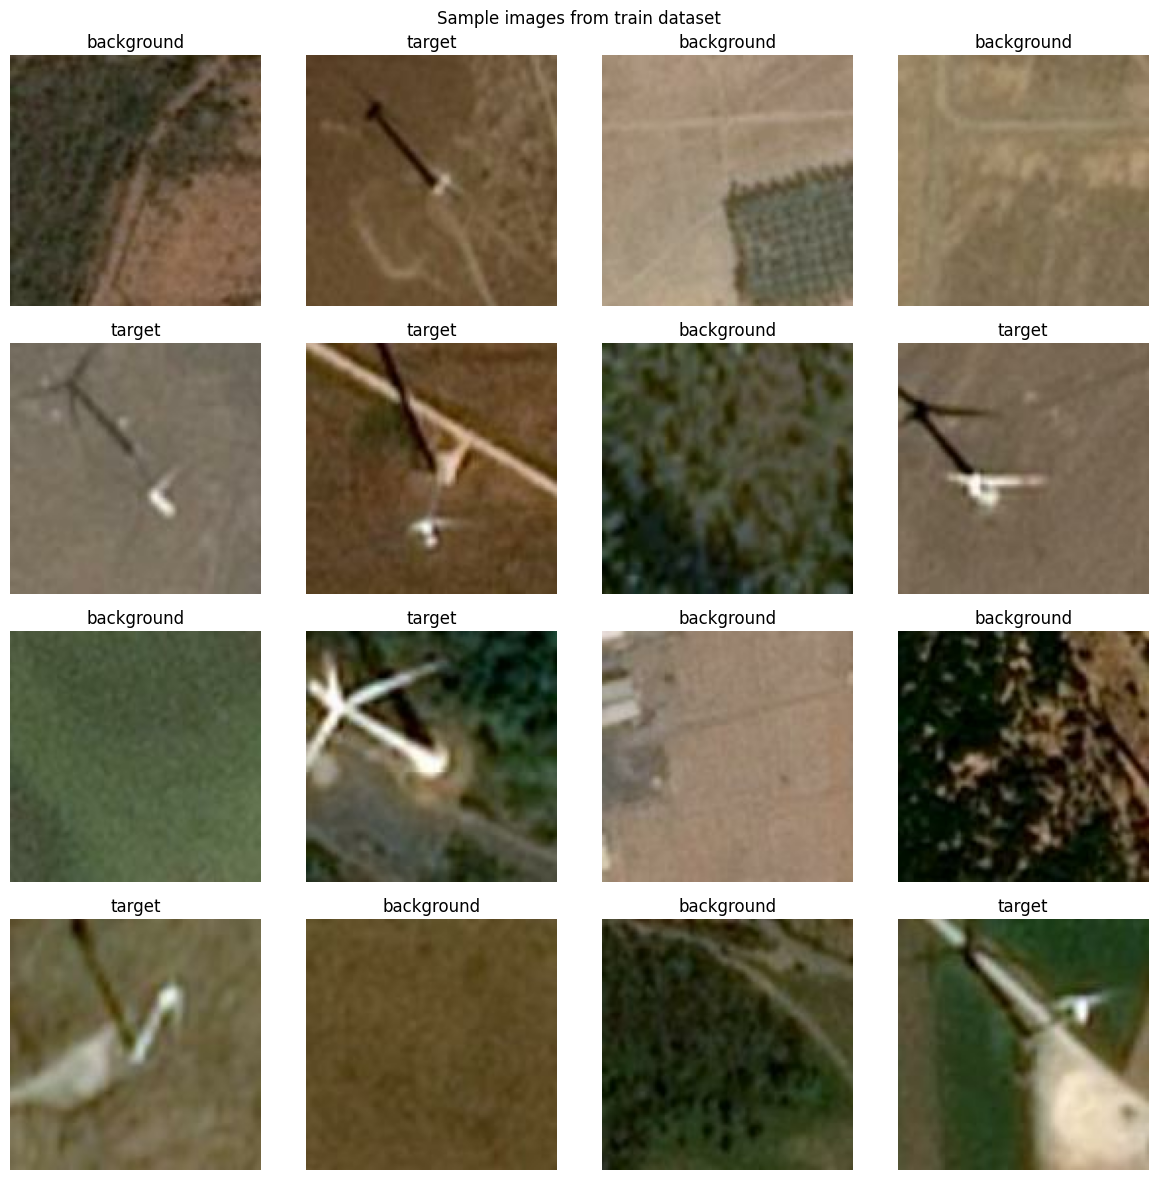

In [15]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for col, (img, label) in enumerate(train_dataset1.take(16)):
    axes[col].imshow(img.numpy())
    title = "target" if label.numpy() == 1 else "background"
    axes[col].set_title(title)
    axes[col].axis('off')

plt.suptitle("Sample images from train dataset")
plt.tight_layout()
plt.show()

The dataset contains images 128x128 - they are all the same size, which can be confirmed by reading the "About Dataset" section from Kaggle. This was also ensured when making the tensorflow dataset objects.

The dataset has color, therefore 3 channels.

The dataset is relatively big, for the porpuse of rapid iteration a sub set of it is going to be selected.

### **Dataset 2**

In [16]:
print("Class distribution across splits:\n")
for name, files, labels in [("Train", train_files2, train_labels2),
                             ("Test",  test_files2,  test_labels2),
                             ("Val",   val_files2,   val_labels2)]:
    n_bg  = (labels == 0).sum()
    n_tgt = (labels > 0).sum()
    total = len(labels)
    print(f"{name:6} | total: {total:6} | background: {n_bg:6} ({n_bg/total:.1%}) | target: {n_tgt:6} ({n_tgt/total:.1%})")

Class distribution across splits:

Train  | total:    580 | background:    157 (27.1%) | target:    423 (72.9%)
Test   | total:    581 | background:    159 (27.4%) | target:    422 (72.6%)
Val    | total:    581 | background:    141 (24.3%) | target:    440 (75.7%)


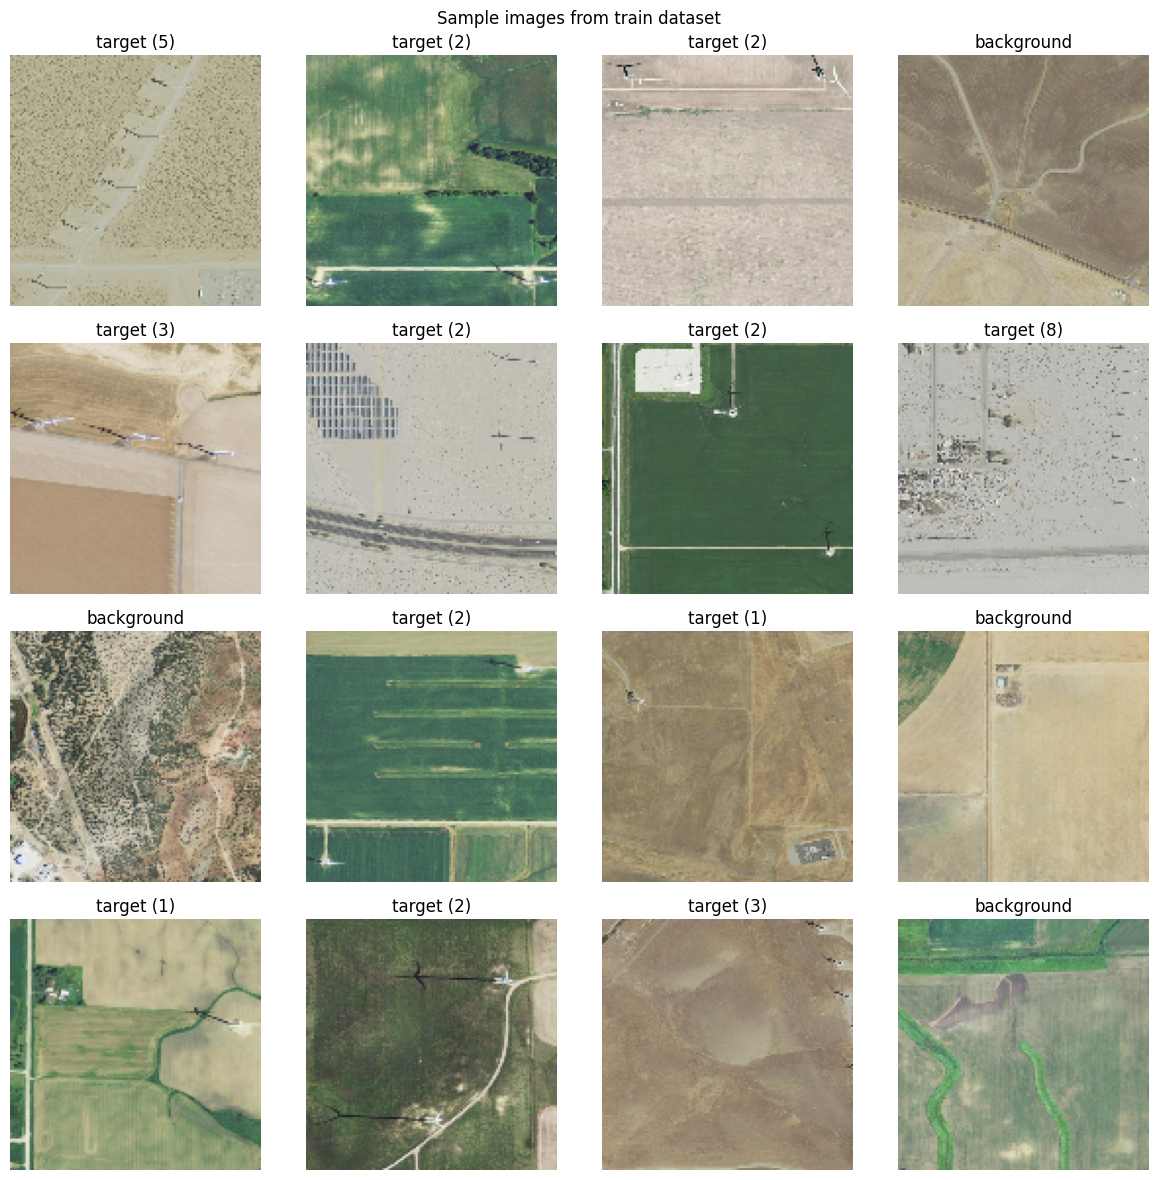

In [17]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for col, (img, label) in enumerate(train_dataset2.take(16)):
    axes[col].imshow(img.numpy())
    title = f"target ({label.numpy()})" if label.numpy() > 0 else "background"
    axes[col].set_title(title)
    axes[col].axis('off')

plt.suptitle("Sample images from train dataset")
plt.tight_layout()
plt.show()

## Transform Data

### **Dataset 1**

#### Create sub-sample

In [18]:
sub_ds_train1 = train_dataset1.take(5000)
sub_ds_test1  = test_dataset1.take(200)
sub_ds_val1   = val_dataset1.take(500)

count_n_images_iterator(sub_ds_train1, 'train'),
count_n_images_iterator(sub_ds_test1, 'test'),
count_n_images_iterator(sub_ds_val1, 'validation')

The train dataset has 5000 images.
The test dataset has 200 images.
The validation dataset has 500 images.


#### Normalize

Here we are normalizing the intensity of each pixel

In [19]:
normalize_ds_train1 = sub_ds_train1.map(normalize_image)
normalize_ds_test1  = sub_ds_test1.map(normalize_image)
normalize_ds_val1   = sub_ds_val1.map(normalize_image)


TypeError: in user code:


    TypeError: outer_factory.<locals>.inner_factory.<locals>.tf__normalize_image() missing 1 required positional argument: 'count'


#### Resize

In [ ]:
# Images are already 128x128 — no resizing needed
resized_ds_train1 = normalize_ds_train1
resized_ds_test1  = normalize_ds_test1
resized_ds_val1   = normalize_ds_val1


#### Batching

In [ ]:
BATCH_SIZE = 32

resized_ds_train1 = resized_ds_train1.map(lambda *x: (x[0], x[1])).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
resized_ds_test1  = resized_ds_test1.map(lambda *x: (x[0], x[1])).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
resized_ds_val1   = resized_ds_val1.map(lambda *x: (x[0], x[1])).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

count_n_images_iterator(resized_ds_train1, 'train', 'batches')
count_n_images_iterator(resized_ds_test1,  'test',  'batches')
count_n_images_iterator(resized_ds_val1,   'validation', 'batches')



The train dataset has 157 batches.
The test dataset has 7 batches.
The validation dataset has 16 batches.


## Modeling - Stage 1 (Binary Classification)

### Baseline

In [ ]:
model_stg1_baseline = Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'), # 32 filters, 3x3 kernel, ReLU activation
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'), # 64 units, ReLU activation
    layers.Dense(1)
])

model_stg1_baseline.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_stg1_baseline.summary()


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 127008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │     8,128,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,129,537 (31.01 MB)

 Trainable params: 8,129,537 (31.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
epochs = 20

history = model_stg1_baseline.fit(
    resized_ds_train1,
    validation_data=resized_ds_val1,
    epochs=epochs
)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 100ms/step - accuracy: 0.8074 - loss: 0.5911 - val_accuracy: 0.9280 - val_loss: 0.2280
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.9266 - loss: 0.1990 - val_accuracy: 0.9380 - val_loss: 0.1623
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 58ms/step - accuracy: 0.9342 - loss: 0.1723 - val_accuracy: 0.9600 - val_loss: 0.1764
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - accuracy: 0.9386 - loss: 0.1718 - val_accuracy: 0.9420 - val_loss: 0.1954
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.9406 - loss: 0.1676 - val_accuracy: 0.9480 - val_loss: 0.1374
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.9490 - loss: 0.1426 - val_accuracy: 0.9360 - val_loss: 0.1646
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 59ms/step - accuracy: 0.9616 - loss: 0.1097 - val_accuracy: 0.9380 - val_loss: 0.1720
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.9596 - loss: 0.0963 - val_a

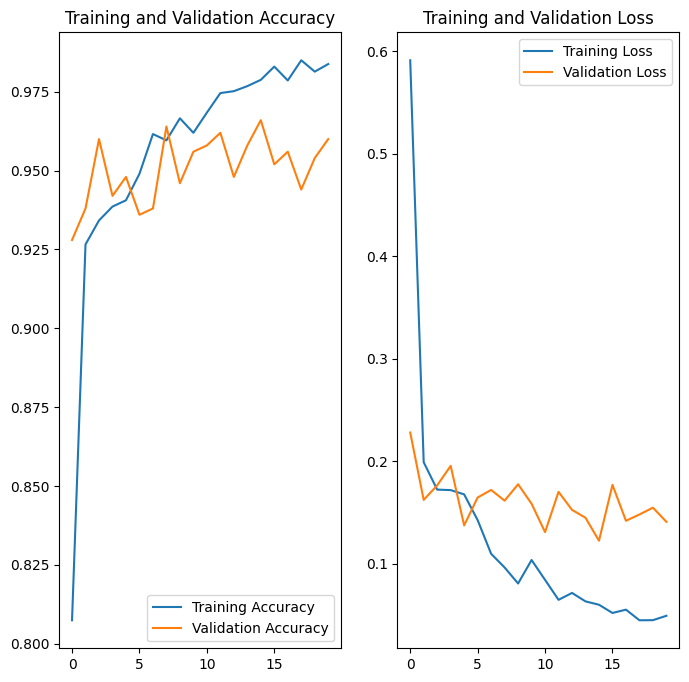

In [ ]:
plot_acuracy_loss(history)

### Increasing complexity (Overfitting)

In [ ]:
model_stg2 = Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(256, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(1)
])

model_stg2.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_stg2.summary()


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,616,001 (17.61 MB)

 Trainable params: 4,616,001 (17.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 30

history = model.fit(
    resized_ds_train,
    validation_data=resized_ds_val,
    epochs=epochs
)

NameError: name 'resized_ds_train' is not defined

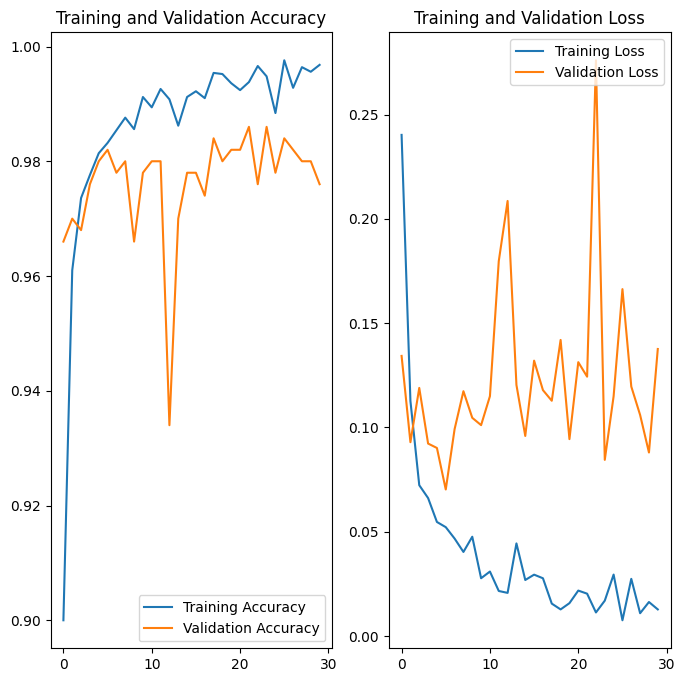

In [ ]:
plot_acuracy_loss(history)

### Fixing Overfitting

- dropout
- regularização
- grayscale
- transfer learning: testar

## The utility of the model (s) created

## Predict for the test set

NameError: name 'nvidia' is not defined

## Future work
